In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from clean.cleaning import clean_data


# --> read df
try:
    df = pd.read_csv("avito_appartements.csv")

    print("read_csv_file and clean_data executed successfully.")

except FileNotFoundError as e:
    print(f"File not found: {e}")
except Exception as e:
    print(f"Error: {e}")

read_csv_file and clean_data executed successfully.


In [32]:
print(df.head())

                   scraped_at  \
0  2026-04-28 18:55:19.764176   
1  2026-04-28 18:55:19.765119   
2  2026-04-28 18:55:19.767028   
3  2026-04-28 18:55:19.768898   
4  2026-04-28 18:55:19.770168   

                                                title      price        city  \
0   Appartement à vendre à Diar Tanger El Moujahidine   430000.0      Tanger   
1             Appartement à vendre 90 m² à Mohammedia  1500000.0  Mohammedia   
2  Penthouse neuf de haut standing à El Menzah (Km17)        NaN   El Menzeh   
3             Appartement 76m Haut Standing Maarif Ex  1100000.0  Casablanca   
4          Appartements de luxe à vendre (Capo Negro)        NaN  Cabo Negro   

           district surface    bedrooms bathrooms            floor  \
0       Moujahidine   56 m²  2 chambres     1 sdb          Étage 2   
1     Autre secteur  103 m²  2 chambres     1 sdb  Rez de chaussée   
2    Toute la ville  242 m²  5 chambres    6 sdbs          Étage 2   
3  Maârif Extension   76 m²  2 chambres 

In [33]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   scraped_at      188 non-null    object 
 1   title           188 non-null    object 
 2   price           171 non-null    float64
 3   city            188 non-null    object 
 4   district        188 non-null    object 
 5   surface         148 non-null    object 
 6   bedrooms        187 non-null    object 
 7   bathrooms       185 non-null    object 
 8   floor           187 non-null    object 
 9   year_built      0 non-null      float64
 10  published_time  188 non-null    object 
 11  url             188 non-null    object 
dtypes: float64(2), object(10)
memory usage: 17.8+ KB
None


In [34]:
print(df.shape)

(188, 12)


In [35]:
print(df.isnull().sum())

scraped_at          0
title               0
price              17
city                0
district            0
surface            40
bedrooms            1
bathrooms           3
floor               1
year_built        188
published_time      0
url                 0
dtype: int64


In [36]:
df.nunique()

scraped_at        188
title             177
price             107
city               30
district           74
surface            89
bedrooms            6
bathrooms           5
floor               8
year_built          0
published_time     58
url               188
dtype: int64

In [37]:
(df.isnull().sum() / len(df)) * 100

scraped_at          0.000000
title               0.000000
price               9.042553
city                0.000000
district            0.000000
surface            21.276596
bedrooms            0.531915
bathrooms           1.595745
floor               0.531915
year_built        100.000000
published_time      0.000000
url                 0.000000
dtype: float64

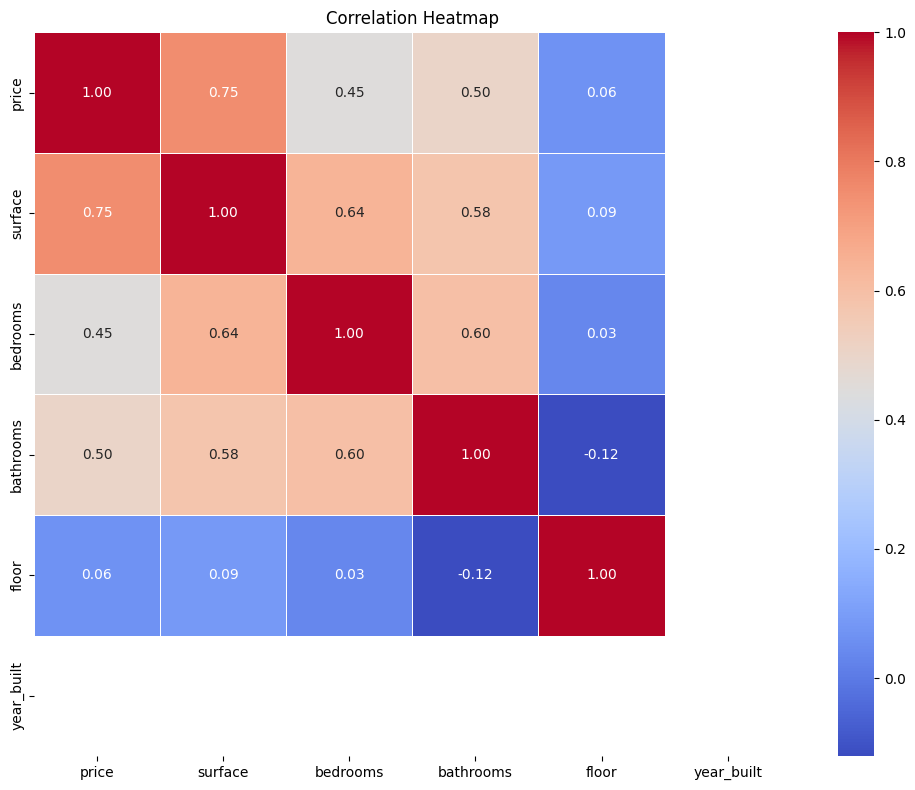

In [40]:

from clean.types import validate_data_types

# --> numeric columns
validate_data_types(df)
numeric_df = df.select_dtypes(include=["number"])

# --> correlation
corr_matrix = numeric_df.corr()

# --> size fig
plt.figure(figsize=(10, 8))

# --> heatmap
sns.heatmap(
    corr_matrix,
    annot=True,       
    cmap="coolwarm",  
    fmt=".2f",       
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [41]:
# --> afficher titel (por visualiser le format de titel)
print(df["title"].head())
print(df["title"].tail())

0     Appartement à vendre à Diar Tanger El Moujahidine
1               Appartement à vendre 90 m² à Mohammedia
2    Penthouse neuf de haut standing à El Menzah (Km17)
3               Appartement 76m Haut Standing Maarif Ex
4            Appartements de luxe à vendre (Capo Negro)
Name: title, dtype: string
183              Appartement à vendre 78 m² à Kénitra
184        Appartement NEUF à vendre 75 m² à Victoria
185    Appartement à vendre 80 m² à le vallon Kénitra
186              Appartement à vendre 74 m² à Kénitra
187                    Studio de Luxe Meublé à vendre
Name: title, dtype: string


In [42]:
# --> aficher url ( pour visualiser le format de url )
pd.set_option("display.max_colwidth", None)

print(df["url"].head())
print(df["url"].tail())

0    https://www.avito.ma/fr/moujahidine/appartements/Appartement_%C3%A0_vendre_%C3%A0_Diar_Tanger_El_Moujahidine_57719086.htm
1       https://www.avito.ma/fr/autre_secteur/appartements/Appartement_%C3%A0_vendre_90_m%C2%B2_%C3%A0_Mohammedia_57723571.htm
2          https://www.avito.ma/fr/el_menzeh/appartements/Penthouse_neuf_de_haut_standing_%C3%A0_El_Menzah__Km17__57711852.htm
3              https://www.avito.ma/fr/ma%C3%A2rif_extension/appartements/Appartement_76m_Haut_Standing_Maarif_Ex_57755690.htm
4                 https://www.avito.ma/fr/cabo_negro/appartements/Appartements_de_luxe_%C3%A0_vendre__Capo_Negro__56898576.htm
Name: url, dtype: string
183              https://www.avito.ma/fr/seyad/appartements/Appartement_%C3%A0_vendre_78_m%C2%B2_%C3%A0_K%C3%A9nitra_57614100.htm
184          https://www.avito.ma/fr/victoria/appartements/Appartement_NEUF_%C3%A0_vendre_75_m%C2%B2_%C3%A0_Victoria_57786394.htm
185    https://www.avito.ma/fr/seyad/appartements/Appartement_%C3%A0_vendre_80_m

In [43]:
# --> les city
print("nomber de city = " , df["city"].nunique())
print(df["city"].unique())

nomber de city =  30
<StringArray>
[     'Tanger',  'Mohammedia',   'El Menzeh',  'Casablanca',  'Cabo Negro',
      'Agadir',   'Marrakech',       'Rabat',     'Kénitra', 'Had Soualem',
      'Saidia',   'Oued Laou',    'Lamkansa',     'Tamesna',        'Salé',
      'Meknès',      'Martil',     'Tamaris',    'Bouznika',         'Fès',
   'Berrechid', 'Dar Bouazza',      'Zenata',   'Bouskoura',  'Sidi Rahal',
      'Deroua',  'Benslimane',      'Mehdia',  'Ben Guerir',      'Temara']
Length: 30, dtype: string


In [44]:
print("nomber de district = " , df["district"].nunique())
print(df["district"].unique())

nomber de district =  74
<StringArray>
[            'Moujahidine',           'Autre secteur',
          'Toute la ville',        'Maârif Extension',
             'Tanja Balia',              'Cité Adrar',
             'Sidi Moumen',                  'Guéliz',
                'Hay Riad',                  'Iberie',
                'alliance',            'Centre Ville',
                'Azzouzia',              'Beauséjour',
                  'Hassan',                  'Centre',
          'Allal El Fassi',           'Hay Mohammadi',
              'nouinouich',                 'Errahma',
               'Bourgogne',                  'Founty',
                 'Marjane',                'Corniche',
           'Triangle d'Or',   'Quartier des Hôpitaux',
              'Val Fleuri',                'Semlalia',
                  'Racine',                 'M'Hamid',
                 'Palmier',              'Said Hajji',
              'Val Fleury',                'Malabata',
                 'Achakar'

In [ ]:
# --> taretib published_time
print(df["published_time"].head(15))
print(df["published_time"].tail(15))

0    2026-04-28 15:55:19.764176
1    2026-04-27 19:55:19.765119
2    2026-04-27 20:55:19.767028
3    2026-04-28 18:52:19.768898
4    2026-04-28 18:51:19.770168
5    2026-04-28 18:51:19.771819
6    2026-04-28 18:50:19.773182
7    2026-04-28 18:49:19.778662
8    2026-04-28 18:49:19.780473
9    2026-04-28 18:49:21.864114
10   2026-04-28 18:49:23.078718
11   2026-04-28 18:49:23.140317
12   2026-04-28 18:48:23.174177
13   2026-04-28 18:47:23.183131
14   2026-04-28 18:44:23.200960
Name: published_time, dtype: datetime64[ns]
173   2026-04-28 17:56:17.800225
174   2026-04-28 17:56:17.809260
175   2026-04-28 17:56:17.844963
176   2026-04-28 17:56:18.206332
177   2026-04-28 17:56:18.222503
178   2026-04-28 17:56:18.721532
179   2026-04-28 17:56:18.869668
180   2026-04-28 17:56:19.201927
181   2026-04-28 17:56:19.430162
182   2026-04-28 17:56:19.450421
183   2026-04-28 17:56:19.535754
184   2026-04-28 17:56:19.597968
185   2026-04-28 17:56:19.969427
186   2026-04-28 17:56:19.987829
187   2026-04-

[ 56. 103. 242.  76. 120. 118.  nan 158. 156. 184.  72.  94.  80.  75.
 164.  68. 113.  70. 108. 131.  81.  87.  60. 150.  89.  84. 165. 250.
  95. 125. 133. 193.  85.  49. 136.  67. 126.  74. 169. 101.  52.  55.
  77. 114. 124. 190. 318.  58.  96. 162.  42.  91.  98. 100.  66. 116.
  46.  65.  44.  73. 199.  50.  90.  59. 123. 117.  97.  99. 160. 170.
 132.  78.  63.  83. 140. 177. 119. 102. 121.  57. 104. 143. 146. 260.
  43.  92. 141. 115.  36.  45.]


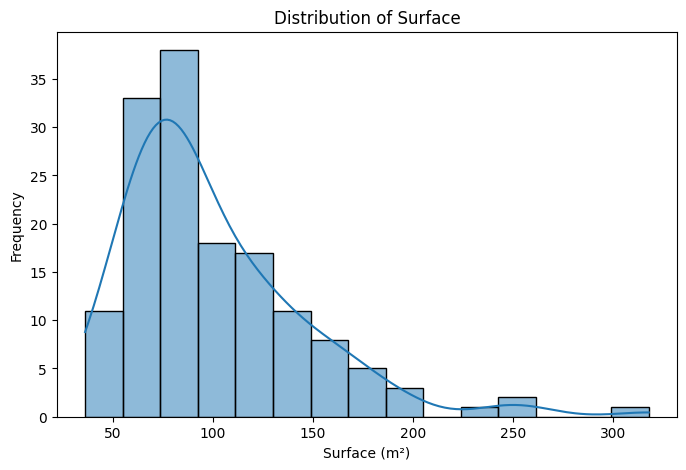

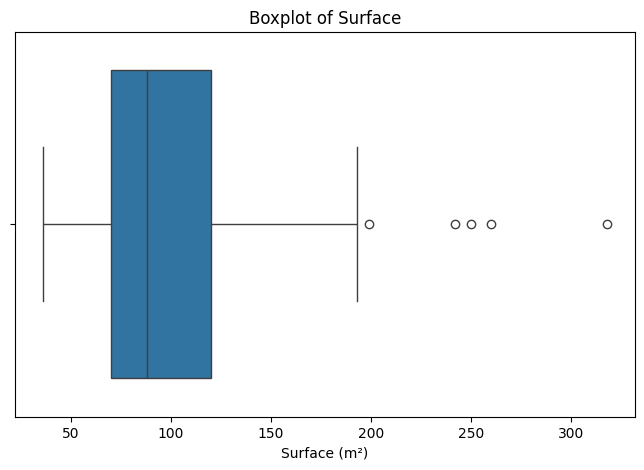

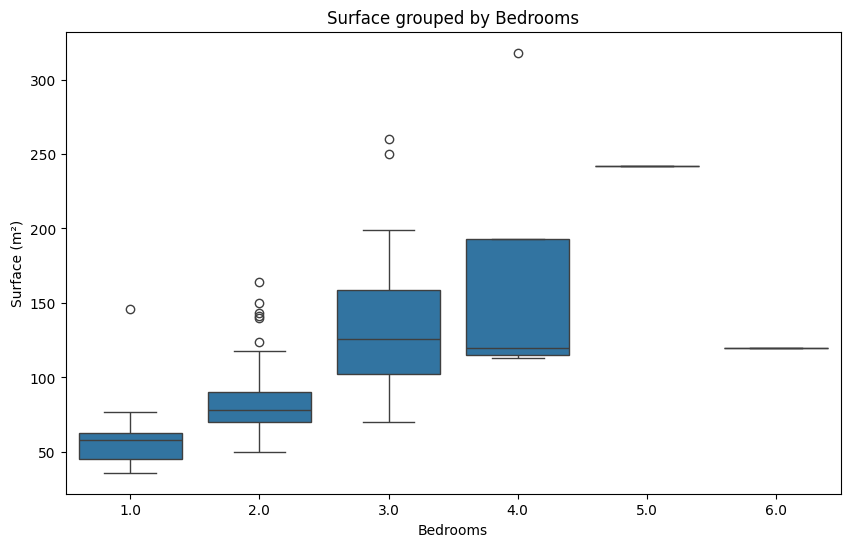

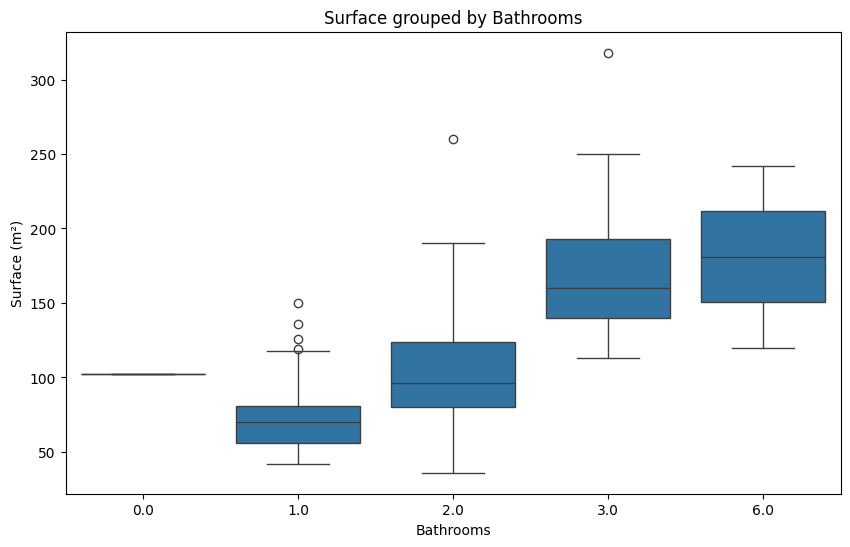

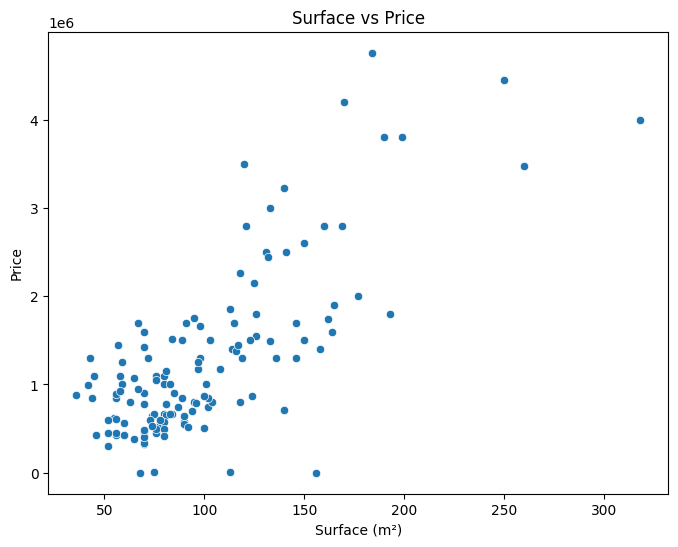

Null values in surface grouped by bedrooms:
bedrooms
1.0     6
2.0    22
3.0    11
4.0     0
5.0     0
6.0     0
Name: surface, dtype: int64


Null values in surface grouped by bathrooms:
bathrooms
0.0     0
1.0    16
2.0    20
3.0     3
6.0     0
Name: surface, dtype: int64


Null values in surface grouped by district:
district
Guéliz            5
Hay Mohammadi     4
Toute la ville    3
Marjane           2
Ain Sebaa         2
                 ..
Sidi Belyout      0
Seyad             0
Triangle d'Or     0
Val Fleury        0
alliance          0
Name: surface, Length: 74, dtype: int64


In [50]:

# --> surface 


# --> afficher les surface
print(df["surface"].unique())


# --> distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df["surface"].dropna(),
    kde=True
)
plt.title("Distribution of Surface")
plt.xlabel("Surface (m²)")
plt.ylabel("Frequency")
plt.show()


# --> Boxplot pour Outliers
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["surface"].dropna()
)
plt.title("Boxplot of Surface")
plt.xlabel("Surface (m²)")
plt.show()


# --> Boxplot grouped by Bedrooms
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bedrooms",
    y="surface",
    data=df
)
plt.title("Surface grouped by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Surface (m²)")
plt.show()


# --> Boxplot grouped by Bathrooms
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bathrooms",
    y="surface",
    data=df
)
plt.title("Surface grouped by Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Surface (m²)")
plt.show()


# --> Scatter Plot (Surface , Price)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="surface",
    y="price",
    data=df
)
plt.title("Surface vs Price")
plt.xlabel("Surface (m²)")
plt.ylabel("Price")
plt.show()


# --> Missing Pattern
print("Null values in surface grouped by bedrooms:")
print(
    df.groupby("bedrooms")["surface"]
    .apply(lambda x: x.isna().sum())
)

print("\n")
print("Null values in surface grouped by bathrooms:")
print(
    df.groupby("bathrooms")["surface"]
    .apply(lambda x: x.isna().sum())
)

print("\n")
print("Null values in surface grouped by district:")
print(
    df.groupby("district")["surface"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)



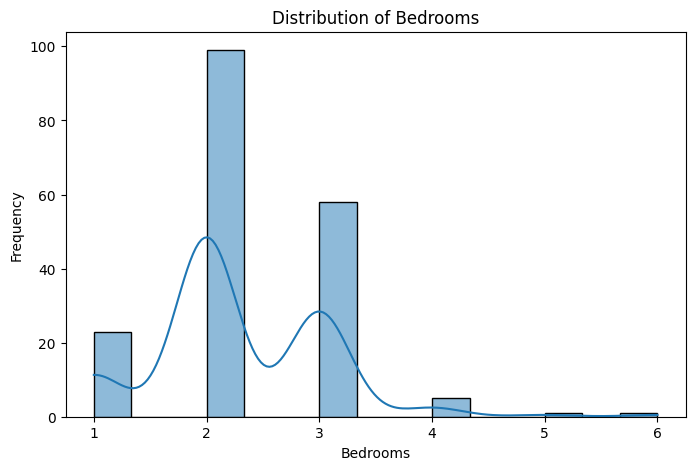

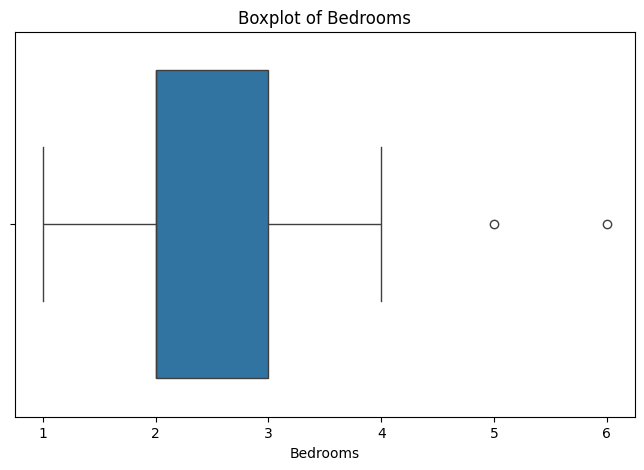

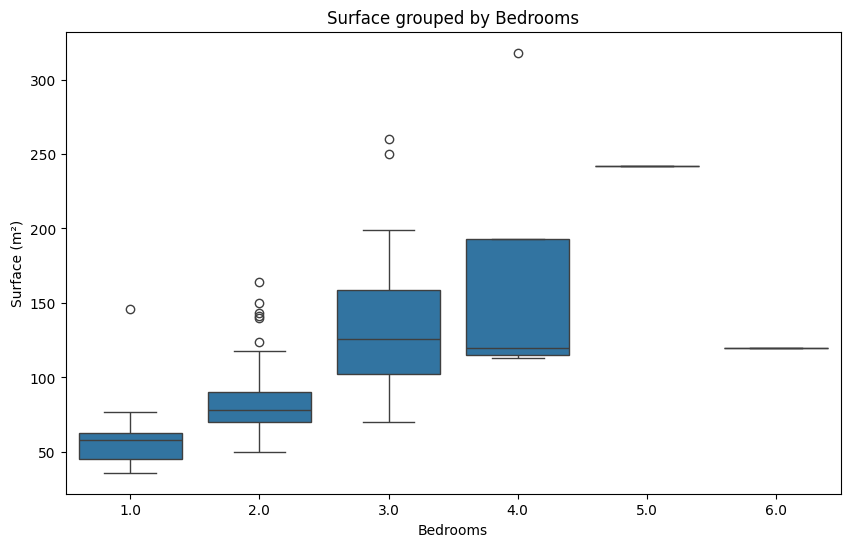

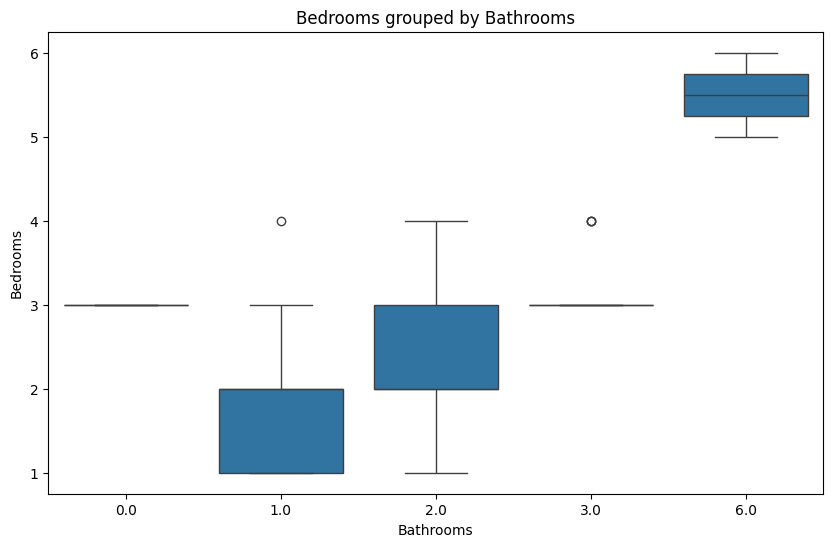

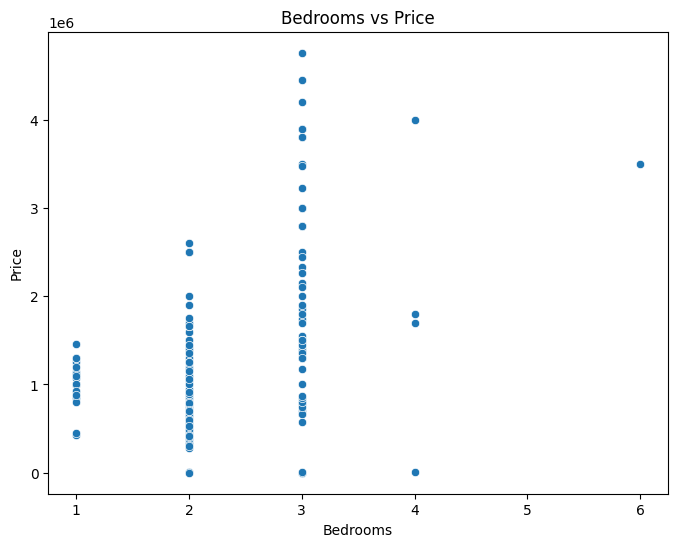

Null values in bedrooms grouped by surface ranges:
surface_group
0-60       0
60-100     0
100-150    0
150-300    0
300+       0
Name: bedrooms, dtype: int64


Null values in bedrooms grouped by bathrooms:
bathrooms
0.0    0
1.0    0
2.0    0
3.0    0
6.0    0
Name: bedrooms, dtype: int64


Null values in bedrooms grouped by district:
district
Hay Mohammadi    1
Achakar          0
Ahlane           0
Ain Mezouar      0
Ain Sebaa        0
                ..
Val Fleury       0
Victoria         0
Ville verte      0
alliance         0
nouinouich       0
Name: bedrooms, Length: 74, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_5040\4146019617.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("surface_group")["bedrooms"]


In [51]:
# --> Bedrooms

# --> Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df["bedrooms"].dropna(),
    kde=True
)
plt.title("Distribution of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Frequency")
plt.show()


# --> Boxplot of Bedrooms
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["bedrooms"].dropna()
)
plt.title("Boxplot of Bedrooms")
plt.xlabel("Bedrooms")
plt.show()


# --> Bedrooms grouped by Surface
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bedrooms",
    y="surface",
    data=df
)
plt.title("Surface grouped by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Surface (m²)")
plt.show()


# --> Bedrooms grouped by Bathrooms
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bathrooms",
    y="bedrooms",
    data=df
)
plt.title("Bedrooms grouped by Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Bedrooms")
plt.show()


# --> Scatter Plot ( Bedrooms , Price )
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="bedrooms",
    y="price",
    data=df
)
plt.title("Bedrooms vs Price")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()


# --> Missing Pattern
print("Null values in bedrooms grouped by surface ranges:")
df["surface_group"] = pd.cut(
    df["surface"],
    bins=[0, 60, 100, 150, 300, 1000],
    labels=[
        "0-60",
        "60-100",
        "100-150",
        "150-300",
        "300+"
    ]
)
print(
    df.groupby("surface_group")["bedrooms"]
    .apply(lambda x: x.isna().sum())
)

print("\n")
print("Null values in bedrooms grouped by bathrooms:")
print(
    df.groupby("bathrooms")["bedrooms"]
    .apply(lambda x: x.isna().sum())
)

print("\n")
print("Null values in bedrooms grouped by district:")
print(
    df.groupby("district")["bedrooms"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)


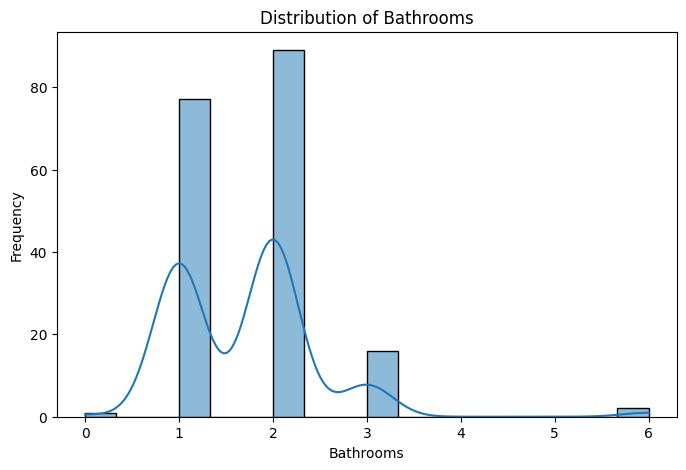

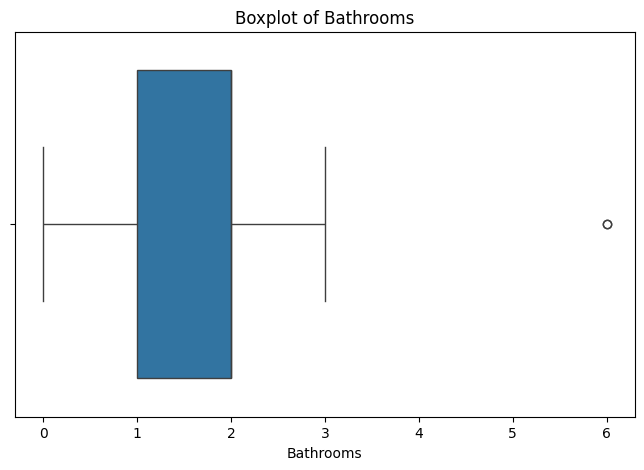

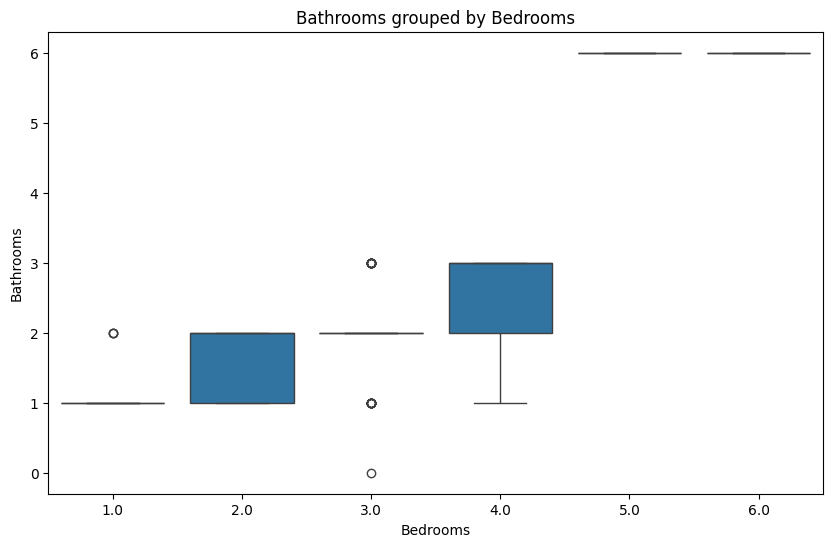

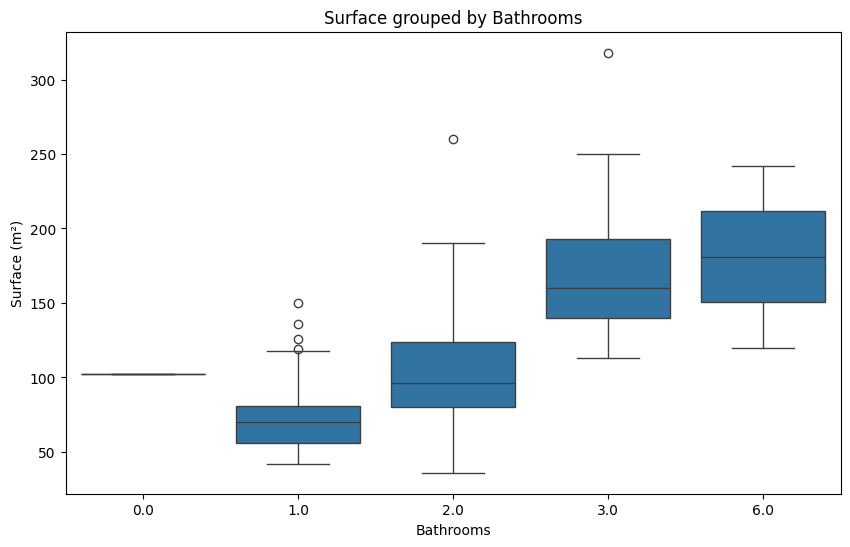

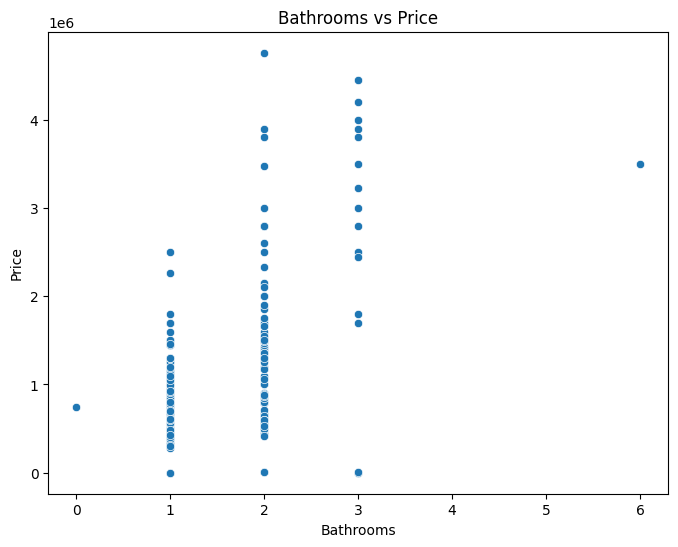

Null values in bathrooms grouped by bedrooms:
bedrooms
1.0    0
2.0    1
3.0    1
4.0    0
5.0    0
6.0    0
Name: bathrooms, dtype: int64


Null values in bathrooms grouped by surface ranges:
surface_group
0-60       0
60-100     1
100-150    0
150-300    1
300+       0
Name: bathrooms, dtype: int64


Null values in bathrooms grouped by district:
district
Maarif           1
Hay Mohammadi    1
Val Fleuri       1
Ahlane           0
Ain Sebaa        0
                ..
Val Fleury       0
Victoria         0
Ville verte      0
alliance         0
nouinouich       0
Name: bathrooms, Length: 74, dtype: int64


C:\Users\Dell\AppData\Local\Temp\ipykernel_5040\3361652469.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("surface_group")["bathrooms"]


In [52]:
# --> Bathrooms



# --> Distribution 
plt.figure(figsize=(8,5))
sns.histplot(
    df["bathrooms"].dropna(),
    kde=True
)
plt.title("Distribution of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Frequency")
plt.show()


# --> Boxplot of Bathrooms
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["bathrooms"].dropna()
)
plt.title("Boxplot of Bathrooms")
plt.xlabel("Bathrooms")
plt.show()


# --> Bathrooms grouped by Bedrooms
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bedrooms",
    y="bathrooms",
    data=df
)
plt.title("Bathrooms grouped by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Bathrooms")
plt.show()


# --> Bathrooms grouped by Surface
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bathrooms",
    y="surface",
    data=df
)
plt.title("Surface grouped by Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Surface (m²)")
plt.show()


# --> Scatter Plot → Bathrooms vs Price
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="bathrooms",
    y="price",
    data=df
)
plt.title("Bathrooms vs Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()


# --> Missing Pattern
print("Null values in bathrooms grouped by bedrooms:")
print(
    df.groupby("bedrooms")["bathrooms"]
    .apply(lambda x: x.isna().sum())
)

print("\n")
print("Null values in bathrooms grouped by surface ranges:")
df["surface_group"] = pd.cut(
    df["surface"],
    bins=[0, 60, 100, 150, 300, 1000],
    labels=[
        "0-60",
        "60-100",
        "100-150",
        "150-300",
        "300+"
    ]
)
print(
    df.groupby("surface_group")["bathrooms"]
    .apply(lambda x: x.isna().sum())
)

print("\n")
print("Null values in bathrooms grouped by district:")
print(
    df.groupby("district")["bathrooms"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)

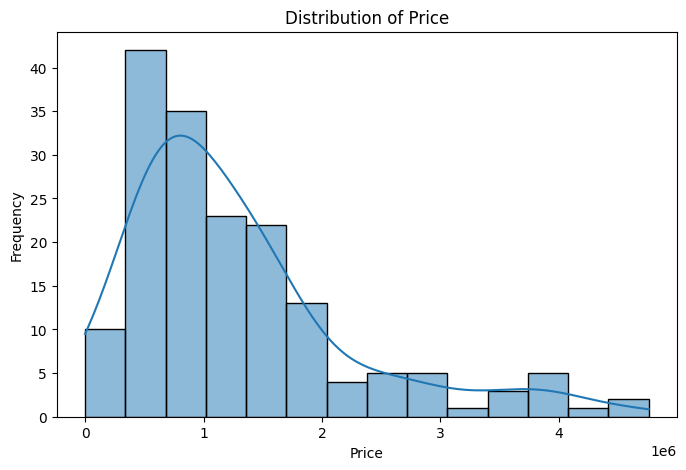

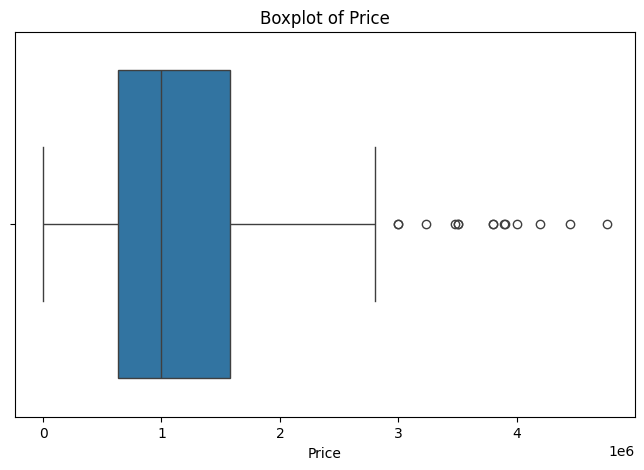

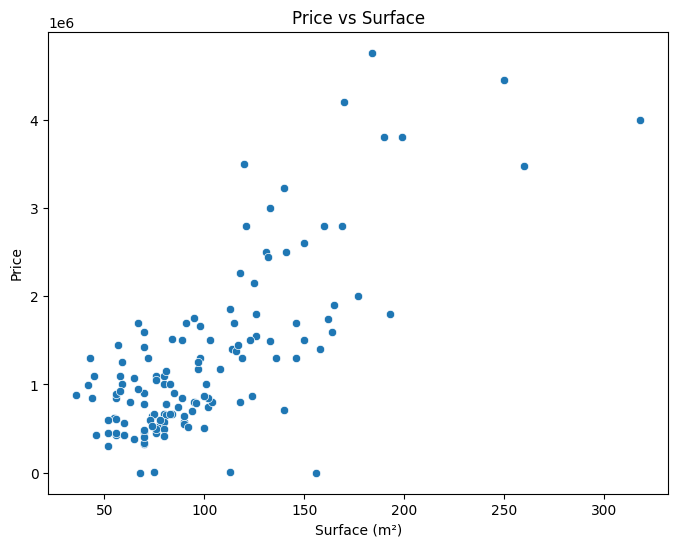

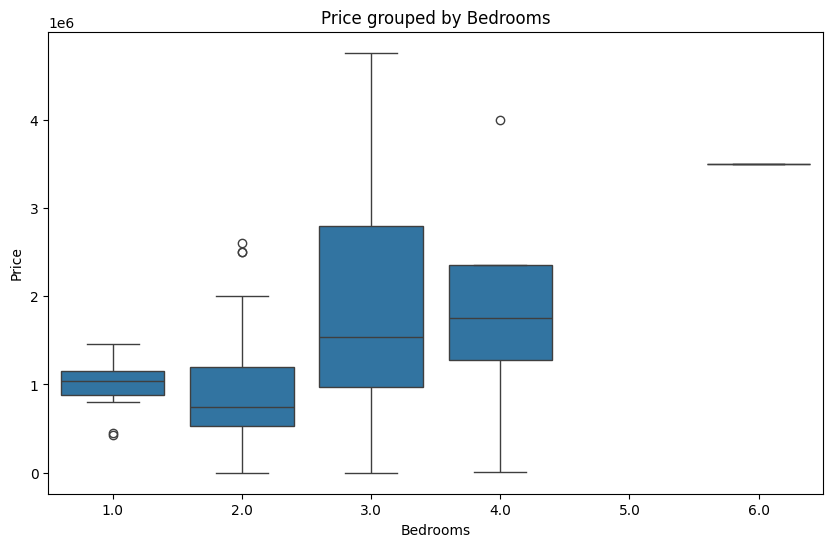

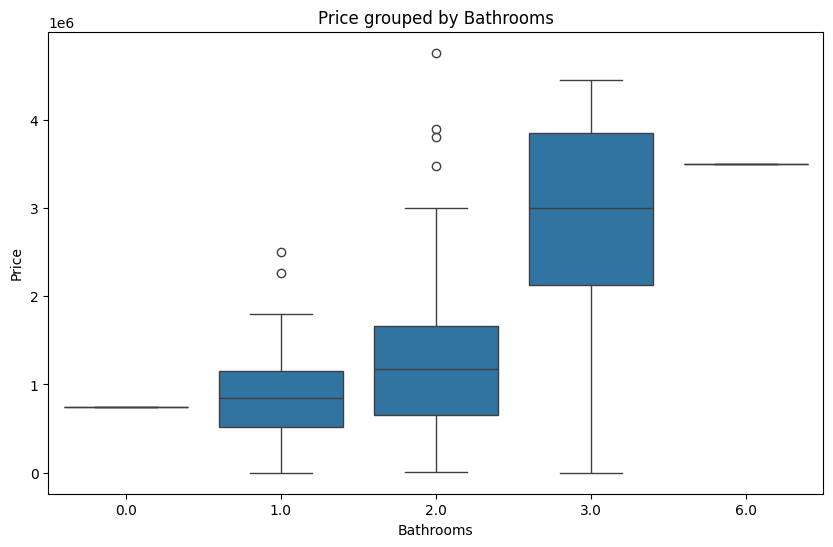

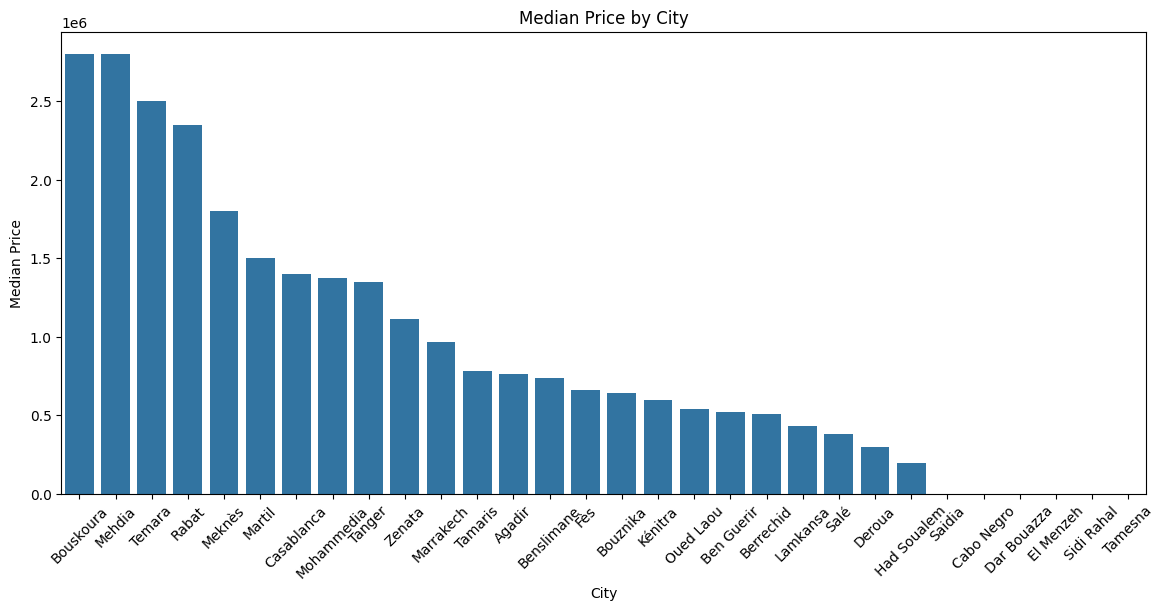

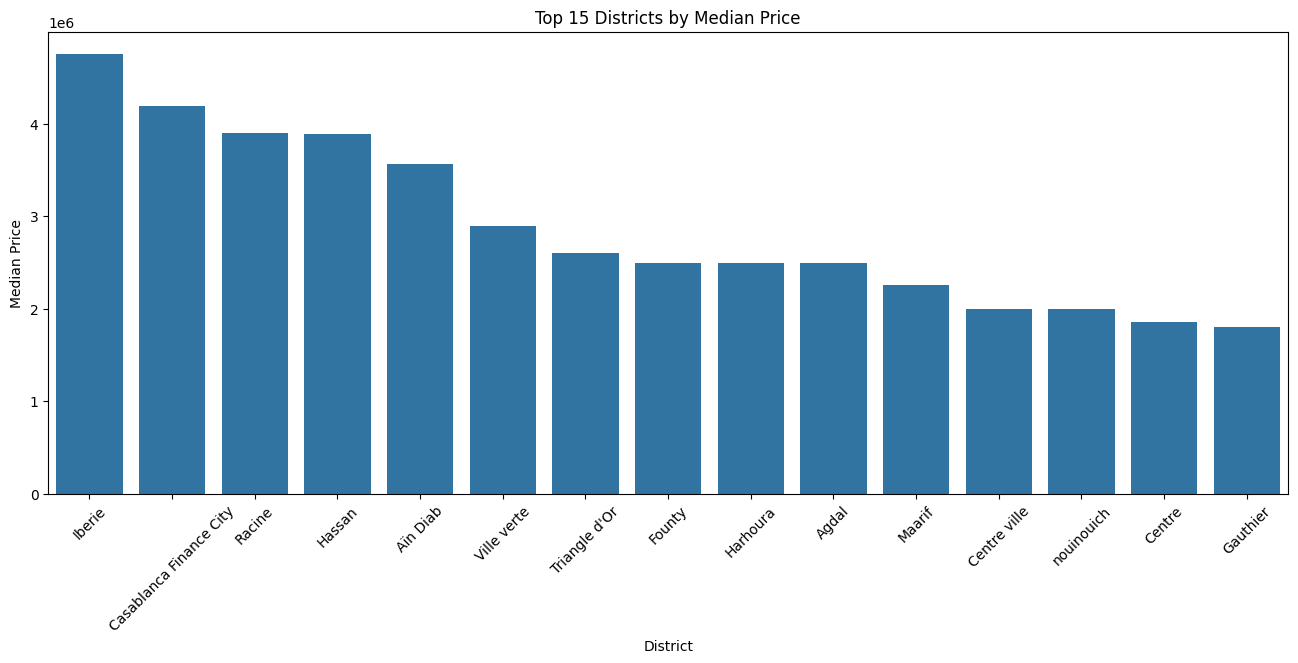

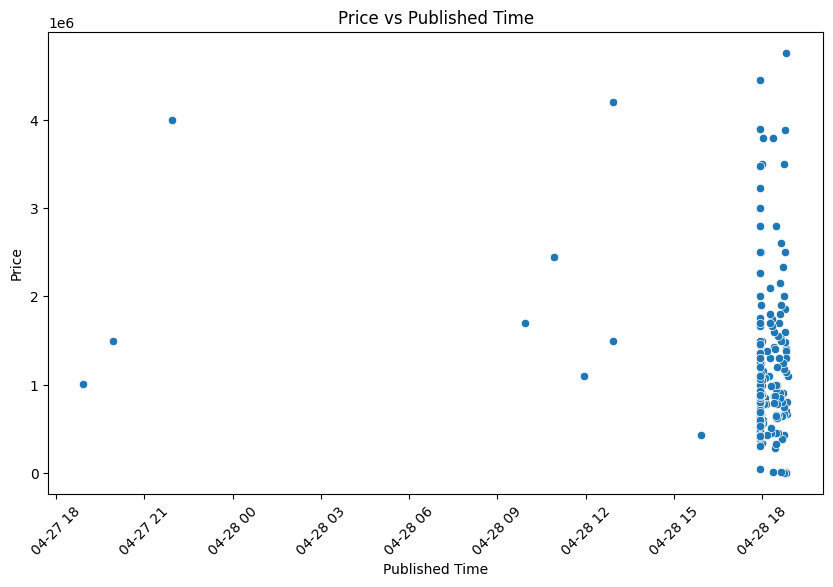

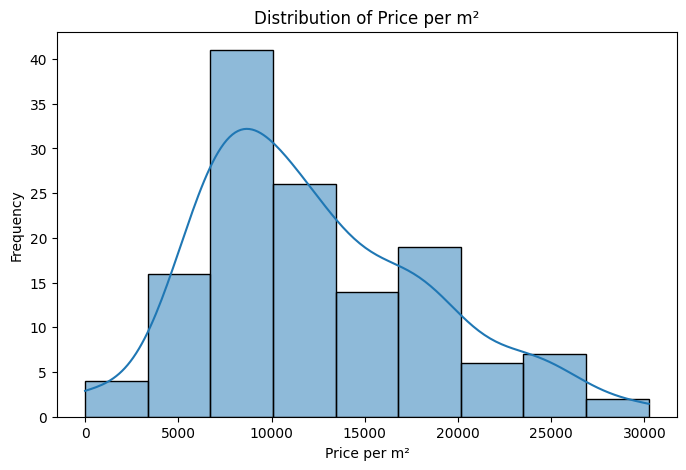

Null values in price grouped by city:
city
Casablanca     4
Marrakech      3
Mohammedia     2
Agadir         2
El Menzeh      1
Dar Bouazza    1
Sidi Rahal     1
Martil         1
Cabo Negro     1
Tamesna        1
Bouznika       0
Bouskoura      0
Berrechid      0
Ben Guerir     0
Kénitra        0
Had Soualem    0
Fès            0
Deroua         0
Benslimane     0
Meknès         0
Mehdia         0
Lamkansa       0
Rabat          0
Oued Laou      0
Salé           0
Saidia         0
Tamaris        0
Tanger         0
Temara         0
Zenata         0
Name: price, dtype: int64


Null values in price grouped by district:
district
Toute la ville      6
Guéliz              3
Hay Mohammadi       2
Hay Hassani         1
Sidi Maarouf        1
Oulfa               1
Autre secteur       1
Quartier du Parc    1
Al Qods             1
Agdal               0
Azzouzia            0
Almaz               0
Allal El Fassi      0
Ain Sebaa           0
Ahlane              0
Ain Mezouar         0
Achakar         

In [53]:
# --> Price



# --> Distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df["price"].dropna(),
    kde=True
)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# --> Boxplot of Price
plt.figure(figsize=(8,5))
sns.boxplot(
    x=df["price"].dropna()
)
plt.title("Boxplot of Price")
plt.xlabel("Price")
plt.show()


# --> Price vs Surface
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="surface",
    y="price",
    data=df
)
plt.title("Price vs Surface")
plt.xlabel("Surface (m²)")
plt.ylabel("Price")
plt.show()


# --> Price grouped by Bedrooms
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bedrooms",
    y="price",
    data=df
)
plt.title("Price grouped by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()


# --> Price grouped by Bathrooms
plt.figure(figsize=(10,6))
sns.boxplot(
    x="bathrooms",
    y="price",
    data=df
)
plt.title("Price grouped by Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.show()


# --> Price grouped by City
plt.figure(figsize=(14,6))
city_price = (
    df.groupby("city")["price"]
    .median()
    .sort_values(ascending=False)
)
sns.barplot(
    x=city_price.index,
    y=city_price.values
)
plt.title("Median Price by City")
plt.xlabel("City")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()


# --> Price grouped by District
plt.figure(figsize=(16,6))
district_price = (
    df.groupby("district")["price"]
    .median()
    .sort_values(ascending=False)
    .head(15)  
)
sns.barplot(
    x=district_price.index,
    y=district_price.values
)
plt.title("Top 15 Districts by Median Price")
plt.xlabel("District")
plt.ylabel("Median Price")
plt.xticks(rotation=45)
plt.show()


# --> Price vs Published Time
plt.figure(figsize=(10,6))
sns.scatterplot(
    x="published_time",
    y="price",
    data=df
)
plt.title("Price vs Published Time")
plt.xlabel("Published Time")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.show()


# --> Price per m²
df["price_per_m2"] = df["price"] / df["surface"]
plt.figure(figsize=(8,5))
sns.histplot(
    df["price_per_m2"].dropna(),
    kde=True
)
plt.title("Distribution of Price per m²")
plt.xlabel("Price per m²")
plt.ylabel("Frequency")
plt.show()


# --> Missing Pattern for Price
print("Null values in price grouped by city:")
print(
    df.groupby("city")["price"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
)
print("\n")


print("Null values in price grouped by district:")
print(
    df.groupby("district")["price"]
    .apply(lambda x: x.isna().sum())
    .sort_values(ascending=False)
    .head(20)
)

print("\n")
print("Null values in price grouped by bedrooms:")
print(
    df.groupby("bedrooms")["price"]
    .apply(lambda x: x.isna().sum())
)

print("\n")
print("Null values in price grouped by bathrooms:")
print(
    df.groupby("bathrooms")["price"]
    .apply(lambda x: x.isna().sum())
)

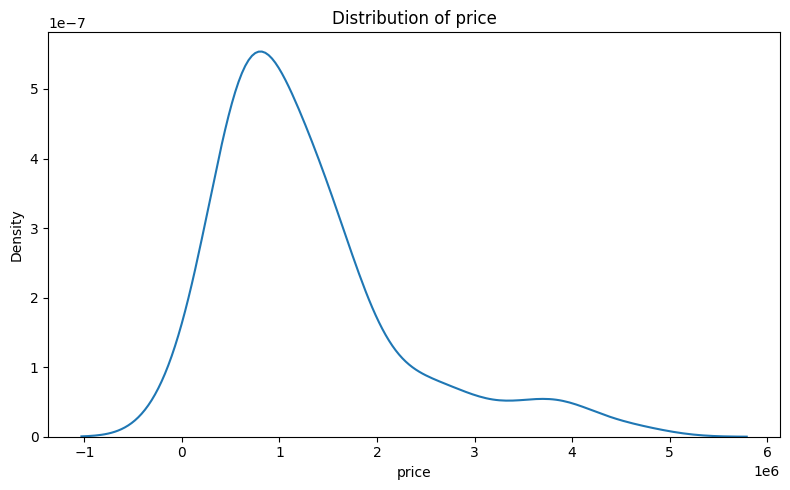

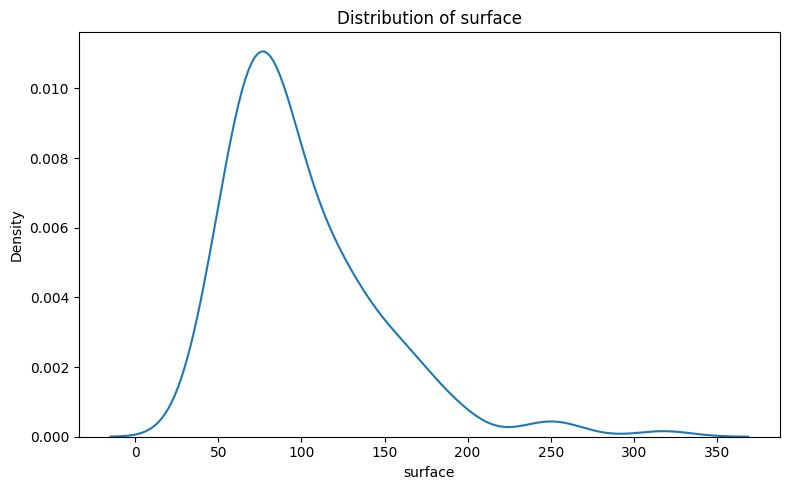

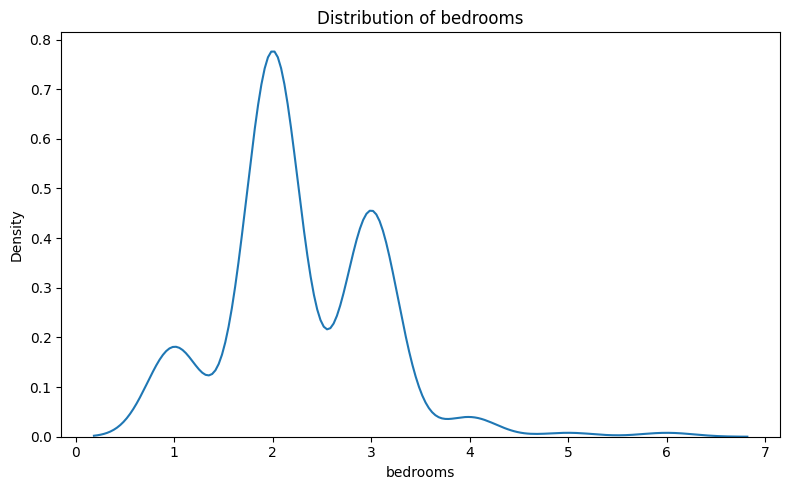

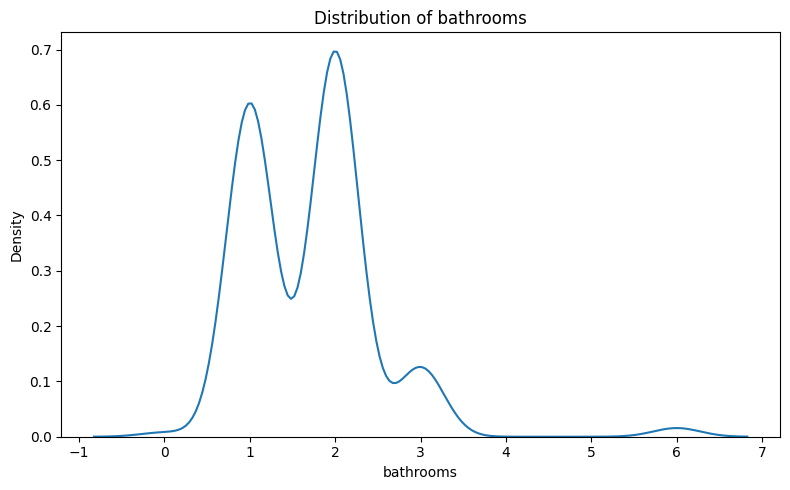

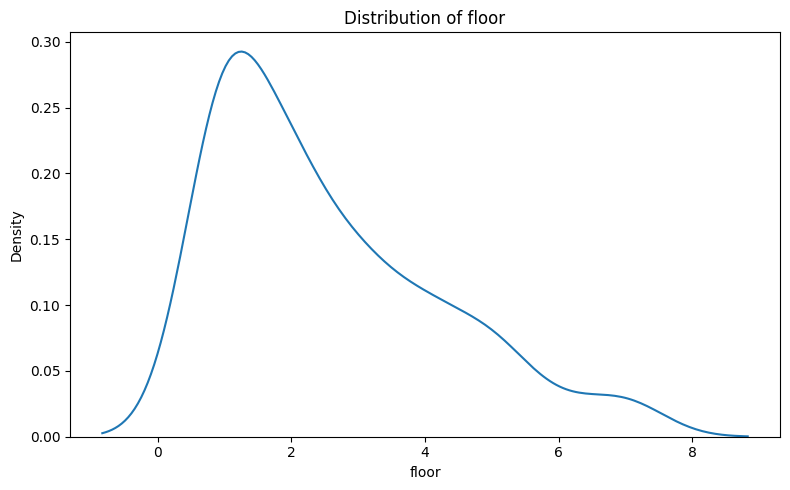

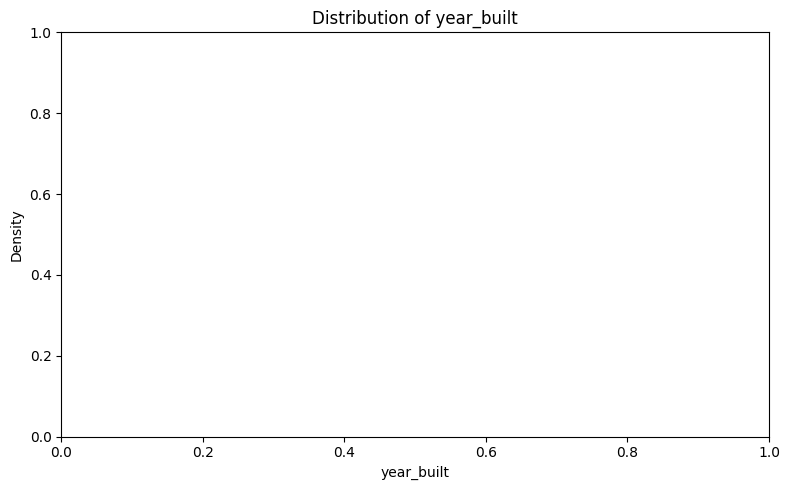

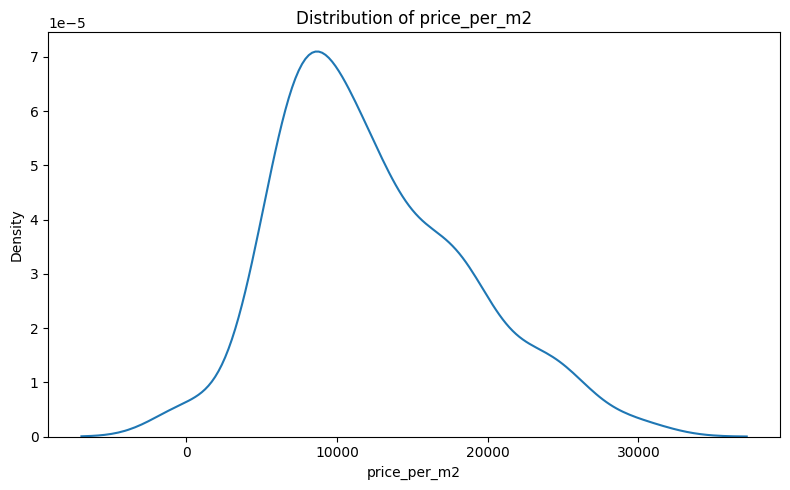

In [54]:


# --> distribution numeric columns
numeric_columns = df.select_dtypes(include=["number"]).columns

for col in numeric_columns:
    plt.figure(figsize=(8, 5))
    sns.kdeplot(
        df[col].dropna(),
        fill=False  
    )
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.tight_layout()
    plt.show()